# Sieć neuronowa

#### Import bibliotek

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import fetch_openml

#### Funkcje do oceny skuteczności

In [2]:
def calculate_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    accuracy = np.trace(cm) / np.sum(cm)
    with np.errstate(divide='ignore', invalid='ignore'):
        sensitivity = np.diag(cm) / np.sum(cm, axis=1)
        specificity = []
        for i in range(len(cm)):
            tn = np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1))
            fp = np.sum(np.delete(cm, i, axis=0)[:, i])
            fn = np.sum(np.delete(cm, i, axis=1)[i, :])
            specificity.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        sensitivity = np.nanmean(sensitivity)
        specificity = np.nanmean(specificity)
    return accuracy, sensitivity, specificity

def plot_roc_curve(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Losowa klasyfikacja')
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('Krzywa ROC')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, labels=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format="d")
    plt.title("Macierz Pomyłek")
    plt.show()

def plot_dataset(X, y, title="Dataset"):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.show()
    
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                             np.arange(y_min, y_max, 0.01))
        
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
        
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap='viridis', s=50)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.show()


### Własna implementacja warstwy

In [3]:
class Layer:
    def __init__(self, n_inputs, n_outputs, activation='relu'):
        self.w = np.random.randn(n_inputs, n_outputs) * np.sqrt(2 / n_inputs)
        self.b = np.zeros((1, n_outputs))
        self.activation = activation

    def activate(self, x):
        self.z = x @ self.w + self.b  
        if self.activation == 'relu':
            self.a = np.maximum(0, self.z)

        elif self.activation == 'sigmoid':
            z_clip = np.clip(self.z, -500, 500) 
            self.a = 1 / (1 + np.exp(-z_clip))

        elif self.activation == 'softmax':
            z_stable = self.z - np.max(self.z, axis=1, keepdims=True)
            exp_z = np.exp(z_stable)
            self.a = exp_z / np.sum(exp_z, axis=1, keepdims=True)

        return self.a


    def activation_derivative(self, x):
        if self.activation == 'relu':
            return (x > 0).astype(float)
        elif self.activation == 'sigmoid':
            sig = 1 / (1 + np.exp(-self.z))
            return sig * (1 - sig)


### Własna implementcja sieci

In [4]:
class NeuralNet:
    def __init__(self, layers_dims, lr=0.01, epochs=1000, activation='relu', batch_size = None):
        self.layers_activation = activation
        self.lr = lr
        self.epochs = epochs
        self.layers = []
        self.batch_size = batch_size if batch_size is not None else layers_dims[0]

        for i in range(len(layers_dims)-2):
            self.layers.append(Layer(layers_dims[i], layers_dims[i+1], activation=self.layers_activation))
        self.layers.append(Layer(layers_dims[-2], layers_dims[-1], activation=self.layers_activation))

    def _forward(self, X):
        a = X
        for layer in self.layers:
            a = layer.activate(a)
        return a

    def _backward(self, X, y_true):
        m = y_true.shape[0]
        y_pred = self.layers[-1].a
        delta = y_pred - y_true

        for i in reversed(range(len(self.layers))):
            a_prev = X if i == 0 else self.layers[i-1].a
            dw = (a_prev.T @ delta) / m
            db = np.sum(delta, axis=0, keepdims=True) / m

            self.layers[i].w -= self.lr * dw
            self.layers[i].b -= self.lr * db

            if i != 0:
                delta = (delta @ self.layers[i].w.T) * self.layers[i-1].activation_derivative(self.layers[i-1].z)

    def train(self, X, y):
        y = np.eye(self.layers[-1].w.shape[1])[y] 
        for _ in range(self.epochs):
            for start in range(0, len(X), self.batch_size):
                end = start + self.batch_size
                X_batch = X[start:end]
                y_batch = y[start:end]

                self._forward(X_batch)
                self._backward(X_batch, y_batch)

    def predict(self, X):
        return np.argmax(self._forward(X), axis=1)


#### Genrowanie danych

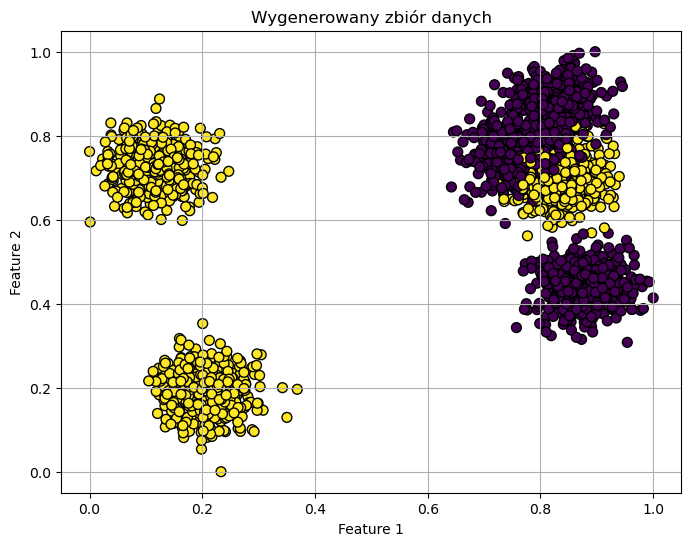

In [5]:
my_index = 259199
my_n_samples = int(str(my_index)[0]+ str(my_index)[1] + str(my_index)[-2] + str(my_index)[-1])

n_features = 2    
n_classes = 2     
n_clusters_per_class = 3

X_blobs, y_blobs = make_blobs(
    n_samples=my_n_samples,
    centers=n_classes * n_clusters_per_class,
    n_features=n_features,
    random_state=my_index
)

scaler = MinMaxScaler()
X_blobs = scaler.fit_transform(X_blobs)

y_blobs = y_blobs % n_classes

plot_dataset(X_blobs, y_blobs, title="Wygenerowany zbiór danych")

#### Podział danych na treningowe i testowe

In [6]:
X_blobs_train, X_blobs_test, y_blobs_train, y_blobs_test = train_test_split(
    X_blobs, y_blobs, test_size=0.2, random_state=my_index
)

print("blobs:", X_blobs_train.shape, y_blobs_train.shape, X_blobs_test.shape, y_blobs_test.shape)

blobs: (2079, 2) (2079,) (520, 2) (520,)


### Porównanie dla 10 czasów

In [9]:
start_time = time.time()
for _ in range(10):
    net = NeuralNet(layers_dims=[2, 10, 10, 2], lr=0.001, epochs=100, activation='relu')
    net.train(X_blobs_train, y_blobs_train)
end_time = time.time()
print(f"ReLu: {end_time - start_time:.2f} s")

start_time = time.time()
for _ in range(10):
    net = NeuralNet(layers_dims=[2, 10, 10, 2], lr=0.001, epochs=100, activation='sigmoid')
    net.train(X_blobs_train, y_blobs_train)
end_time = time.time()
print(f"Sigmoid: {end_time - start_time:.2f} s")

ReLu: 89.25 s
Sigmoid: 161.34 s


### Trening na syntetycznym zbiorze wielomodowym

Relu

Dokładność: 0.9481, Czułość: 0.9481, Specyficzność: 0.9481


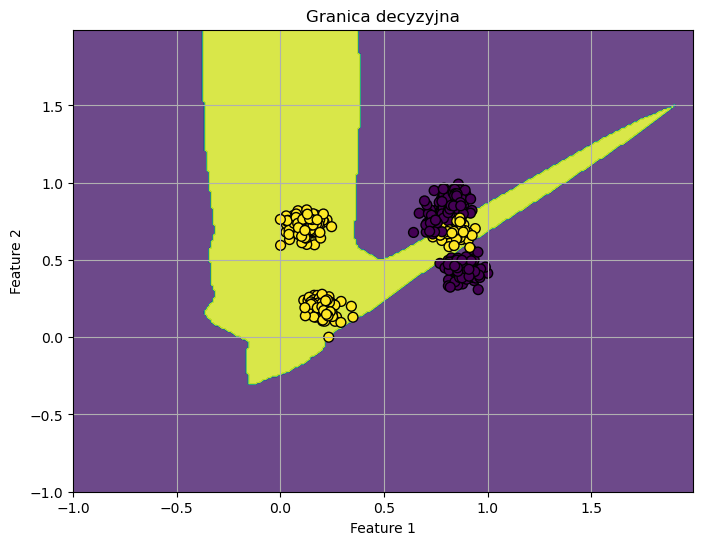

<Figure size 600x600 with 0 Axes>

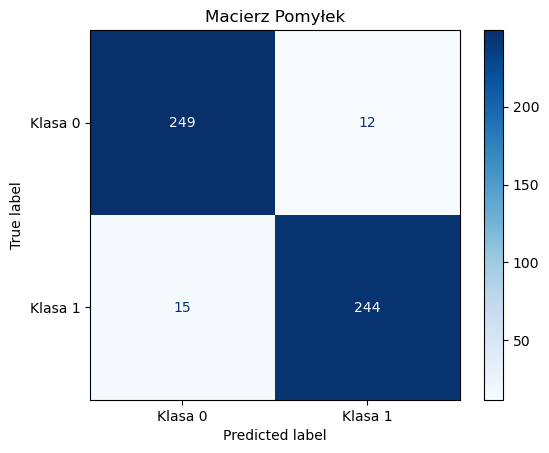

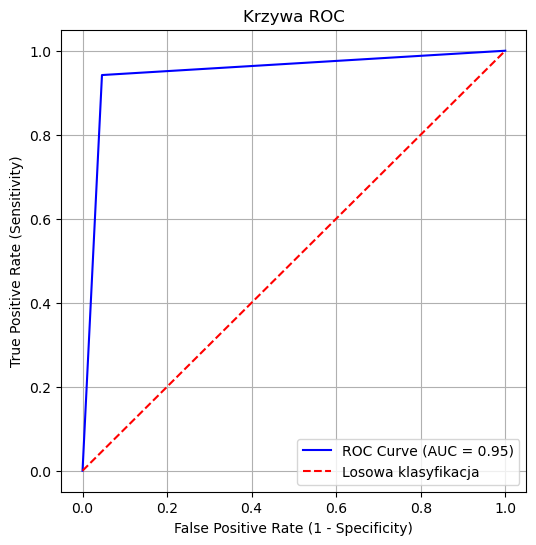

In [ ]:
net = NeuralNet(layers_dims=[2, 32, 32, 16, 2], lr=0.01, epochs=5000, activation='relu')
net.train(X_blobs_train, y_blobs_train)

y_pred = net.predict(X_blobs_test)
acc = accuracy_score(y_blobs_test, y_pred)

accuracy, sensitivity, specificity = calculate_metrics(y_blobs_test, y_pred)
print(f"Dokładność: {acc:.4f}, Czułość: {sensitivity:.4f}, Specyficzność: {specificity:.4f}")
plot_decision_boundary(net, X_blobs_test, y_blobs_test, title="Granica decyzyjna")
plot_confusion_matrix(y_blobs_test, y_pred, labels=["Klasa 0", "Klasa 1"])
plot_roc_curve(y_blobs_test, y_pred)

Sigmoid

Dokładność: 0.8385, Czułość: 0.8378, Specyficzność: 0.8378


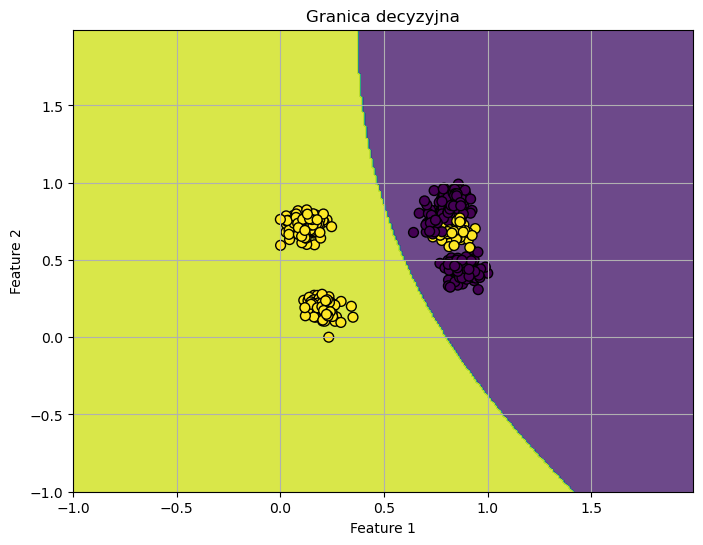

<Figure size 600x600 with 0 Axes>

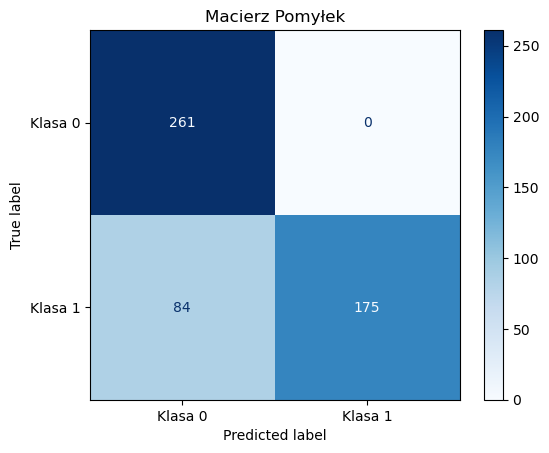

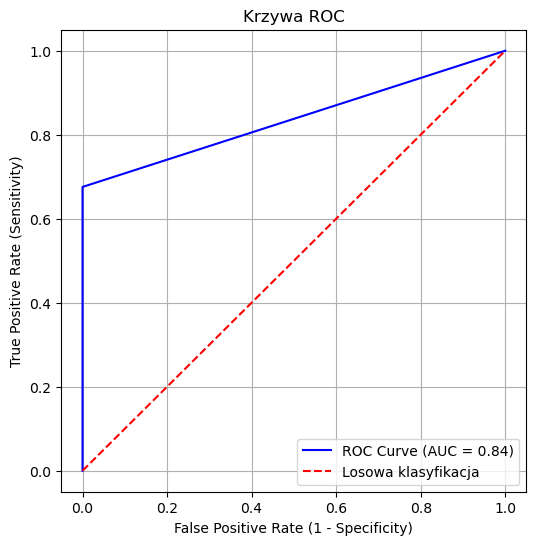

In [ ]:
net = NeuralNet(layers_dims=[2, 32, 32, 16, 2], lr=0.01, epochs=5000, activation='sigmoid')
net.train(X_blobs_train, y_blobs_train)

y_pred = net.predict(X_blobs_test)
acc = accuracy_score(y_blobs_test, y_pred)

accuracy, sensitivity, specificity = calculate_metrics(y_blobs_test, y_pred)
print(f"Dokładność: {acc:.4f}, Czułość: {sensitivity:.4f}, Specyficzność: {specificity:.4f}")
plot_decision_boundary(net, X_blobs_test, y_blobs_test, title="Granica decyzyjna")
plot_confusion_matrix(y_blobs_test, y_pred, labels=["Klasa 0", "Klasa 1"])
plot_roc_curve(y_blobs_test, y_pred)

### MNIST

In [11]:
mnist = fetch_openml('mnist_784')

In [12]:
mnist.data

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
69996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
69997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
69998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


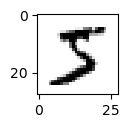

In [13]:
image = mnist.data.to_numpy()

plt.subplot(431)
plt.imshow((image[0].reshape(28,28)), cmap=plt.cm.gray_r, interpolation='nearest')

#### Podział na trenignowe i testowe

In [14]:
X = mnist.data.to_numpy() / 255.0
y = mnist.target.to_numpy().astype(int)

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, train_size=0.1, random_state=my_index, shuffle=True
)

print("mnist:", x_train.shape, y_train.shape, x_test.shape, y_test.shape)

mnist: (7000, 784) (7000,) (14000, 784) (14000,)


#### Relu

Całkowity czas: 68.18 s, czas predykcji: 0.07 s
Dokładność: 0.9443, Czułość: 0.9437, Specyficzność: 0.9938


<Figure size 600x600 with 0 Axes>

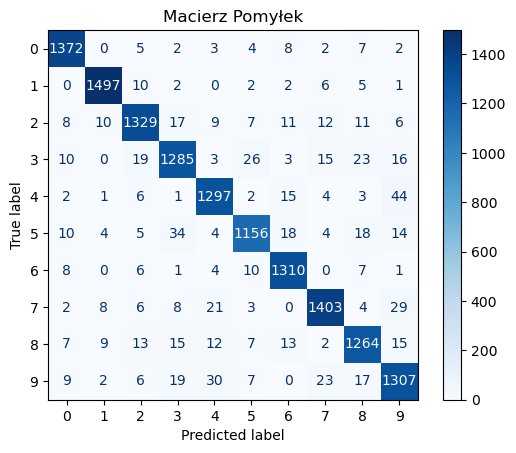

In [20]:
net = NeuralNet(layers_dims=[784, 128, 64, 10], lr=0.01, epochs=500, activation='relu', batch_size=100)
start_time = time.time()
net.train(x_train, y_train)
start_prediction_time = time.time()
y_pred = net.predict(x_test)
end_time = time.time()
print(f"Całkowity czas: {end_time - start_time:.2f} s, czas predykcji: {end_time - start_prediction_time:.2f} s")

accuracy, sensitivity, specificity = calculate_metrics(y_test, y_pred)
print(f"Dokładność: {accuracy:.4f}, Czułość: {sensitivity:.4f}, Specyficzność: {specificity:.4f}")
plot_confusion_matrix(y_test, y_pred, labels=np.unique(y_test))

#### Sigmoid

Całkowity czas treningu: 77.19 s, czas predykcji: 0.12 s
Dokładność: 0.9478, Czułość: 0.9475, Specyficzność: 0.9942


<Figure size 600x600 with 0 Axes>

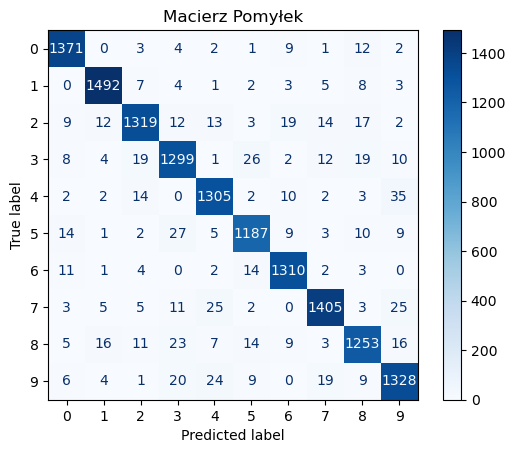

In [22]:
net = NeuralNet(layers_dims=[784, 128, 64, 10], lr=0.1, epochs=500, activation='sigmoid', batch_size=100)
start_time = time.time()
net.train(x_train, y_train)
start_prediction = time.time()
y_pred = net.predict(x_test)
end_time = time.time()
print(f"Całkowity czas treningu: {end_time - start_time:.2f} s, czas predykcji: {end_time - start_prediction:.2f} s")

accuracy, sensitivity, specificity = calculate_metrics(y_test, y_pred)
print(f"Dokładność: {accuracy:.4f}, Czułość: {sensitivity:.4f}, Specyficzność: {specificity:.4f}")
plot_confusion_matrix(y_test, y_pred, labels=np.unique(y_test))